# Comprehensive Airline Delay Analysis

This notebook analyzes flight delays across all airlines based on:
- `Airline_Delay_Cause.csv` - Complete flight delay data for all airlines

## Dataset Overview
The dataset contains information about:
- Years and months (2013-2023)
- All airlines and airports
- Number of flights and delayed flights
- Delay categories (carrier, weather, NAS, security, late aircraft)
- Delay times in minutes

## Analysis Focus
- Airline comparison
- Identification of main delay categories
- Temporal trends and patterns
- Decision support for airline selection


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported!")


Libraries imported!


In [2]:
# Load Airline Delay Cause dataset
airline_df = pd.read_csv('../dataset/airline_delays.csv')

print("Airline Delay Cause dataset loaded!")
print(f"Dataset size: {airline_df.shape}")


Airline Delay Cause dataset loaded!
Dataset size: (171666, 21)


## 1. Dataset Exploration


In [3]:
# Basic information about Airline Delay Cause dataset
print("=== AIRLINE DELAY CAUSE DATASET ===")
print(f"Number of rows: {len(airline_df)}")
print(f"Number of columns: {len(airline_df.columns)}")
print("\nColumns:")
print(airline_df.columns.tolist())
print("\nFirst 5 rows:")
airline_df.head()


=== AIRLINE DELAY CAUSE DATASET ===
Number of rows: 171666
Number of columns: 21

Columns:
['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name', 'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']

First 5 rows:


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [4]:
# Basic information about Airline Delay Cause dataset
print("=== AIRLINE DELAY CAUSE DATASET ===")
print(f"Number of rows: {len(airline_df)}")
print(f"Number of columns: {len(airline_df.columns)}")
print("\nColumns:")
print(airline_df.columns.tolist())
print("\nFirst 5 rows:")
airline_df.head()


=== AIRLINE DELAY CAUSE DATASET ===
Number of rows: 171666
Number of columns: 21

Columns:
['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name', 'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']

First 5 rows:


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [5]:
# Data quality check
print("=== DATA QUALITY CHECK ===")
print(f"Missing values: {airline_df.isnull().sum().sum()}")
print(f"Duplicate rows: {airline_df.duplicated().sum()}")

# Check data types
print("\nData types:")
print(airline_df.dtypes)

# Unique airlines and airports
print(f"\nNumber of unique airlines: {airline_df['carrier_name'].nunique()}")
print(f"Number of unique airports: {airline_df['airport'].nunique()}")
print(f"Time span: {airline_df['year'].min()}-{airline_df['year'].max()}")


=== DATA QUALITY CHECK ===
Missing values: 3803
Duplicate rows: 0

Data types:
year                     int64
month                    int64
carrier                 object
carrier_name            object
airport                 object
airport_name            object
arr_flights            float64
arr_del15              float64
carrier_ct             float64
weather_ct             float64
nas_ct                 float64
security_ct            float64
late_aircraft_ct       float64
arr_cancelled          float64
arr_diverted           float64
arr_delay              float64
carrier_delay          float64
weather_delay          float64
nas_delay              float64
security_delay         float64
late_aircraft_delay    float64
dtype: object

Number of unique airlines: 23
Number of unique airports: 395
Time span: 2013-2023


## 2. Descriptive Analysis


In [6]:
# Statistical summary for all airlines
print("=== AIRLINE DELAY CAUSE STATISTICS ===")
print(airline_df.describe())


=== AIRLINE DELAY CAUSE STATISTICS ===
                year          month    arr_flights      arr_del15  \
count  171666.000000  171666.000000  171426.000000  171223.000000   
mean     2018.551361       6.493633     362.528467      66.434387   
std         2.890006       3.440908     992.894662     179.540694   
min      2013.000000       1.000000       1.000000       0.000000   
25%      2016.000000       4.000000      50.000000       6.000000   
50%      2019.000000       7.000000     100.000000      17.000000   
75%      2021.000000       9.000000     250.000000      47.000000   
max      2023.000000      12.000000   21977.000000    4176.000000   

          carrier_ct     weather_ct         nas_ct    security_ct  \
count  171426.000000  171426.000000  171426.000000  171426.000000   
mean       20.796615       2.250347      19.381147       0.157096   
std        50.315176       7.314252      61.675244       0.717405   
min         0.000000       0.000000       0.000000       0.0000

In [7]:
# Analysis of years, months and airlines
print("=== TEMPORAL AND AIRLINE ANALYSIS ===")
print(f"Years: {sorted(airline_df['year'].unique())}")
print(f"Months: {sorted(airline_df['month'].unique())}")
print(f"Number of unique airports: {airline_df['airport'].nunique()}")

# Top 10 airlines by number of flights
print(f"\nTop 10 airlines by number of flights:")
top_carriers = airline_df.groupby('carrier_name')['arr_flights'].sum().nlargest(10)
print(top_carriers)


=== TEMPORAL AND AIRLINE ANALYSIS ===
Years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Number of unique airports: 395

Top 10 airlines by number of flights:
carrier_name
Southwest Airlines Co.      12522217.0
Delta Air Lines Inc.         8661561.0
American Airlines Inc.       7973061.0
SkyWest Airlines Inc.        6905056.0
United Air Lines Inc.        5464237.0
ExpressJet Airlines Inc.     2637669.0
JetBlue Airways              2609697.0
Envoy Air                    2073685.0
Alaska Airlines Inc.         1990957.0
Republic Airline             1717781.0
Name: arr_flights, dtype: float64


In [8]:
# Analysis of years, months and airlines
print("=== TEMPORAL AND AIRLINE ANALYSIS ===")
print(f"Years: {sorted(airline_df['year'].unique())}")
print(f"Months: {sorted(airline_df['month'].unique())}")
print(f"Number of unique airports: {airline_df['airport'].nunique()}")

# Top 10 airlines by number of flights
print(f"\nTop 10 airlines by number of flights:")
top_carriers = airline_df.groupby('carrier_name')['arr_flights'].sum().nlargest(10)
print(top_carriers)


=== TEMPORAL AND AIRLINE ANALYSIS ===
Years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Number of unique airports: 395

Top 10 airlines by number of flights:
carrier_name
Southwest Airlines Co.      12522217.0
Delta Air Lines Inc.         8661561.0
American Airlines Inc.       7973061.0
SkyWest Airlines Inc.        6905056.0
United Air Lines Inc.        5464237.0
ExpressJet Airlines Inc.     2637669.0
JetBlue Airways              2609697.0
Envoy Air                    2073685.0
Alaska Airlines Inc.         1990957.0
Republic Airline             1717781.0
Name: arr_flights, dtype: float64


## 3. Visualizations


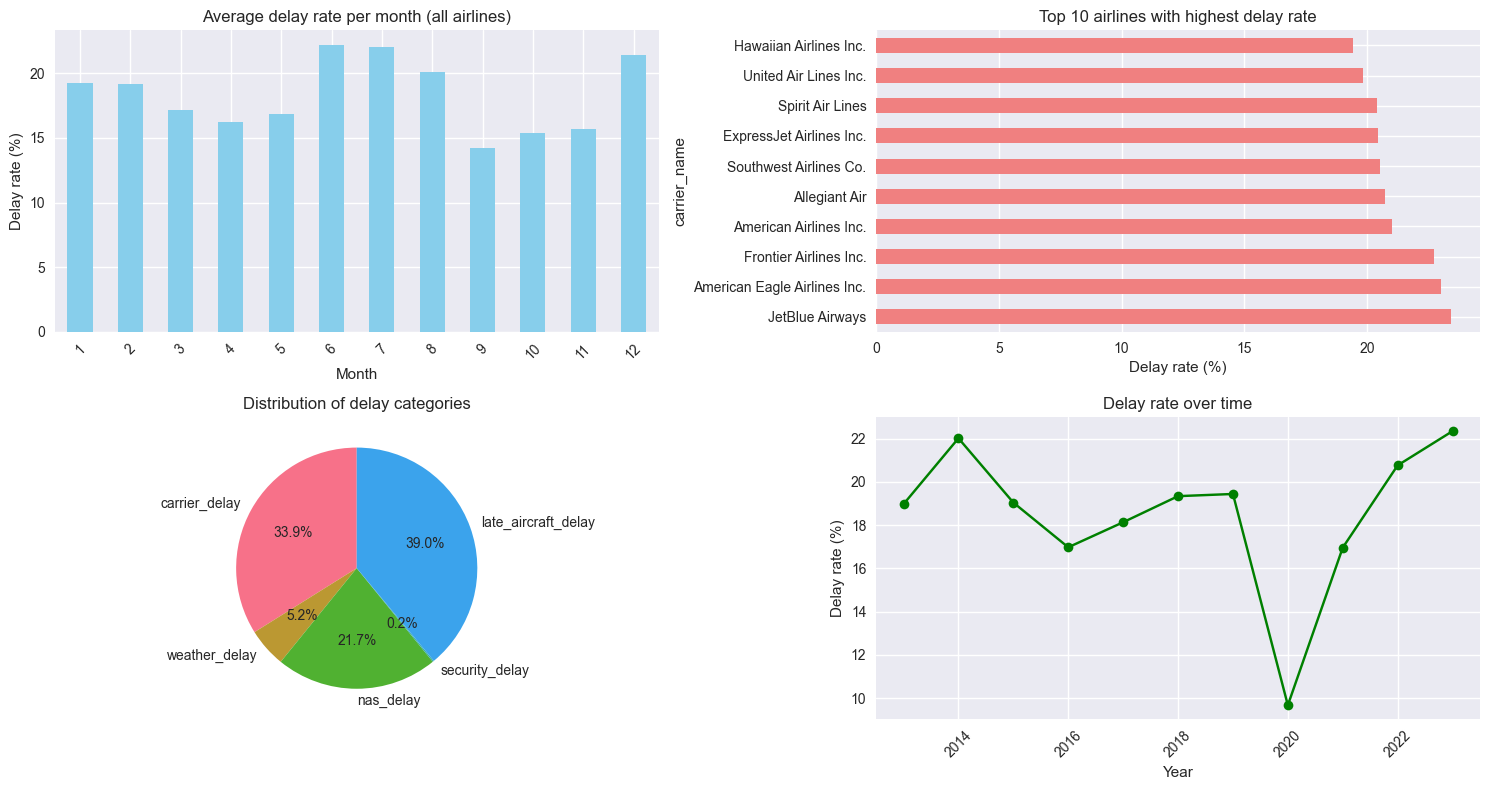

In [9]:
# 1. Delay rate over time (all airlines)
plt.figure(figsize=(15, 8))

# Calculate delay rate
airline_df['delay_rate'] = (airline_df['arr_del15'] / airline_df['arr_flights']) * 100

# Group by month
monthly_delays = airline_df.groupby('month')['delay_rate'].mean()

plt.subplot(2, 2, 1)
monthly_delays.plot(kind='bar', color='skyblue')
plt.title('Average delay rate per month (all airlines)')
plt.xlabel('Month')
plt.ylabel('Delay rate (%)')
plt.xticks(rotation=45)

# 2. Top 10 airlines by delay rate
plt.subplot(2, 2, 2)
carrier_delay_rates = airline_df.groupby('carrier_name')['delay_rate'].mean()
top_delay_carriers = carrier_delay_rates.nlargest(10)
top_delay_carriers.plot(kind='barh', color='lightcoral')
plt.title('Top 10 airlines with highest delay rate')
plt.xlabel('Delay rate (%)')

# 3. Delay categories distribution
plt.subplot(2, 2, 3)
delay_categories = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
total_delays_by_category = airline_df[delay_categories].sum()
total_delays_by_category.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Distribution of delay categories')
plt.ylabel('')

# 4. Annual trends
plt.subplot(2, 2, 4)
yearly_delays = airline_df.groupby('year')['delay_rate'].mean()
yearly_delays.plot(kind='line', marker='o', color='green')
plt.title('Delay rate over time')
plt.xlabel('Year')
plt.ylabel('Delay rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


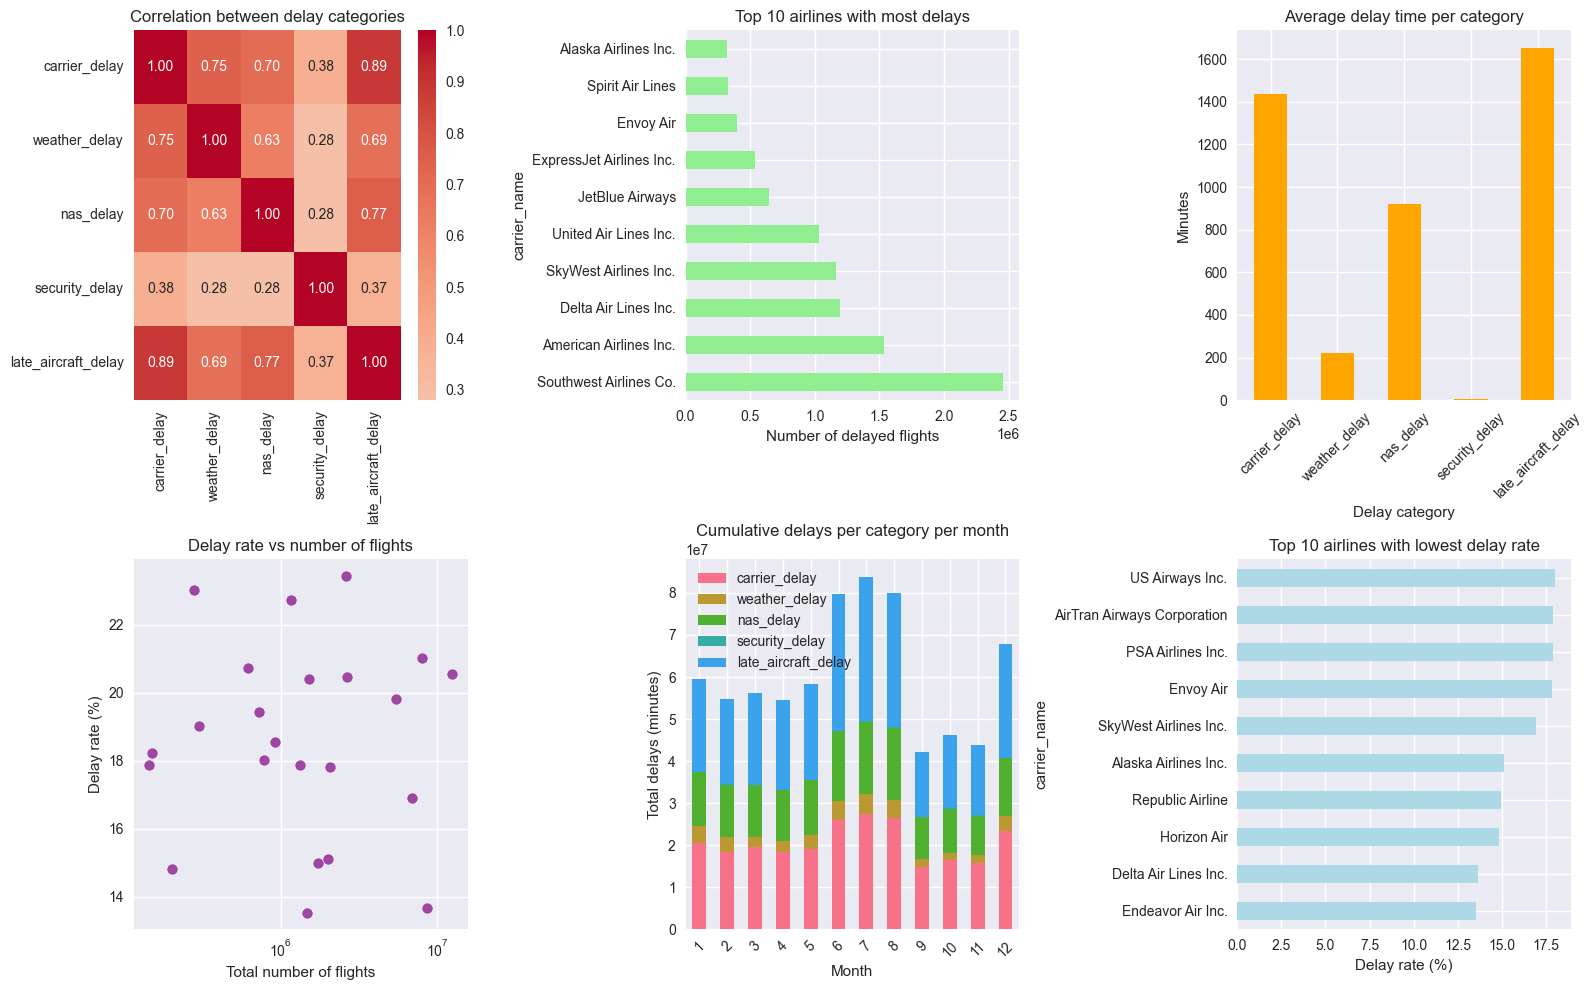

In [10]:
# Detailed analysis of delay categories and airlines
plt.figure(figsize=(16, 10))

# 1. Correlation between delay categories
plt.subplot(2, 3, 1)
delay_categories = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
correlation_matrix = airline_df[delay_categories].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation between delay categories')

# 2. Top airlines by total delays
plt.subplot(2, 3, 2)
total_delays_by_carrier = airline_df.groupby('carrier_name')['arr_del15'].sum().nlargest(10)
total_delays_by_carrier.plot(kind='barh', color='lightgreen')
plt.title('Top 10 airlines with most delays')
plt.xlabel('Number of delayed flights')

# 3. Average delay time per category
plt.subplot(2, 3, 3)
avg_delay_time = airline_df[delay_categories].mean()
avg_delay_time.plot(kind='bar', color='orange')
plt.title('Average delay time per category')
plt.xlabel('Delay category')
plt.ylabel('Minutes')
plt.xticks(rotation=45)

# 4. Delay rate vs number of flights (scatter)
plt.subplot(2, 3, 4)
carrier_stats = airline_df.groupby('carrier_name').agg({
    'arr_flights': 'sum',
    'delay_rate': 'mean'
}).reset_index()
plt.scatter(carrier_stats['arr_flights'], carrier_stats['delay_rate'], alpha=0.7, color='purple')
plt.xlabel('Total number of flights')
plt.ylabel('Delay rate (%)')
plt.title('Delay rate vs number of flights')
plt.xscale('log')

# 5. Monthly trends for main categories
plt.subplot(2, 3, 5)
monthly_category_delays = airline_df.groupby('month')[delay_categories].sum()
monthly_category_delays.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Cumulative delays per category per month')
plt.xlabel('Month')
plt.ylabel('Total delays (minutes)')
plt.xticks(rotation=45)

# 6. Best airlines (lowest delay rate)
plt.subplot(2, 3, 6)
best_carriers = carrier_delay_rates.nsmallest(10)
best_carriers.plot(kind='barh', color='lightblue')
plt.title('Top 10 airlines with lowest delay rate')
plt.xlabel('Delay rate (%)')

plt.tight_layout()
plt.show()


## 4. Statistical Insights and Conclusions


In [11]:
# Statistical summary and insights
print("=== KEY INSIGHTS AND CONCLUSIONS ===")

# General overview
print("\n1. GENERAL SUMMARY:")
print(f"   • Average delay rate: {airline_df['delay_rate'].mean():.2f}%")
print(f"   • Median delay rate: {airline_df['delay_rate'].median():.2f}%")
print(f"   • Total number of flights: {airline_df['arr_flights'].sum():,.0f}")
print(f"   • Total number of delayed flights: {airline_df['arr_del15'].sum():,.0f}")

# Delay categories
print(f"\n2. DELAY CATEGORIES:")
delay_categories = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
total_delay_minutes = airline_df[delay_categories].sum().sum()
for category in delay_categories:
    total_delay = airline_df[category].sum()
    percentage = (total_delay / total_delay_minutes) * 100
    print(f"   • {category.replace('_', ' ').title()}: {total_delay:,.0f} minutes ({percentage:.1f}%)")

# Best and worst airlines
print(f"\n3. AIRLINE RANKING:")
best_carrier = airline_df.groupby('carrier_name')['delay_rate'].mean().nsmallest(1)
worst_carrier = airline_df.groupby('carrier_name')['delay_rate'].mean().nlargest(1)
print(f"   • Best airline: {best_carrier.index[0]} ({best_carrier.iloc[0]:.2f}%)")
print(f"   • Worst airline: {worst_carrier.index[0]} ({worst_carrier.iloc[0]:.2f}%)")

# Monthly trends
print(f"\n4. MONTHLY TRENDS:")
worst_month = airline_df.groupby('month')['delay_rate'].mean().idxmax()
best_month = airline_df.groupby('month')['delay_rate'].mean().idxmin()
print(f"   • Worst month: {worst_month} ({airline_df.groupby('month')['delay_rate'].mean()[worst_month]:.2f}%)")
print(f"   • Best month: {best_month} ({airline_df.groupby('month')['delay_rate'].mean()[best_month]:.2f}%)")

# Annual trends
print(f"\n5. ANNUAL TRENDS:")
worst_year = airline_df.groupby('year')['delay_rate'].mean().idxmax()
best_year = airline_df.groupby('year')['delay_rate'].mean().idxmin()
print(f"   • Worst year: {worst_year} ({airline_df.groupby('year')['delay_rate'].mean()[worst_year]:.2f}%)")
print(f"   • Best year: {best_year} ({airline_df.groupby('year')['delay_rate'].mean()[best_year]:.2f}%)")

print(f"\n6. RECOMMENDATIONS:")
print(f"   • Choose airlines with lowest delay rates for better reliability")
print(f"   • Avoid traveling in month {worst_month} if possible")
print(f"   • Carrier and Late Aircraft delays are the biggest problems")
print(f"   • Weather and NAS delays are less controllable factors")


=== KEY INSIGHTS AND CONCLUSIONS ===

1. GENERAL SUMMARY:
   • Average delay rate: 18.34%
   • Median delay rate: 17.07%
   • Total number of flights: 62,146,805
   • Total number of delayed flights: 11,375,095

2. DELAY CATEGORIES:
   • Carrier Delay: 246,370,897 minutes (33.9%)
   • Weather Delay: 38,153,170 minutes (5.2%)
   • Nas Delay: 157,823,639 minutes (21.7%)
   • Security Delay: 1,265,591 minutes (0.2%)
   • Late Aircraft Delay: 283,144,335 minutes (39.0%)

3. AIRLINE RANKING:
   • Best airline: Endeavor Air Inc. (13.53%)
   • Worst airline: JetBlue Airways (23.43%)

4. MONTHLY TRENDS:
   • Worst month: 6 (22.20%)
   • Best month: 9 (14.23%)

5. ANNUAL TRENDS:
   • Worst year: 2023 (22.35%)
   • Best year: 2020 (9.68%)

6. RECOMMENDATIONS:
   • Choose airlines with lowest delay rates for better reliability
   • Avoid traveling in month 6 if possible
   • Carrier and Late Aircraft delays are the biggest problems
   • Weather and NAS delays are less controllable factors
